In [17]:
from sentence_transformers import SentenceTransformer, util
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
# Define 10 sentences across 3 topics:
sentences = [
    "I saw that six cleared the stadium.",
    "Fielding in slip position is all about reflexes, split second decision making is necessary.",
    "T20 format cricket is the best form of modern day cricket.",
    "The meat was so tender that it fell of the bones.",
    "Sautéing onions until golden brown makes curry have deep umami flavour.",
    "Kesar is the best aromatic for Biryani and Pilaaf",
    "Baking bread from scratch requires patience and experience",
    "Multi-factor authentication assures peace of mind of an added layer of security.",
    "Phishing attacks are often hard to notice if you are not cautious enough.",
    "Updating your software regularly  "
]

# Load the model and generate embeddings

model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

print(f"Embeddings generated! Shape: {embeddings.shape}")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embeddings generated! Shape: (10, 384)


In [14]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

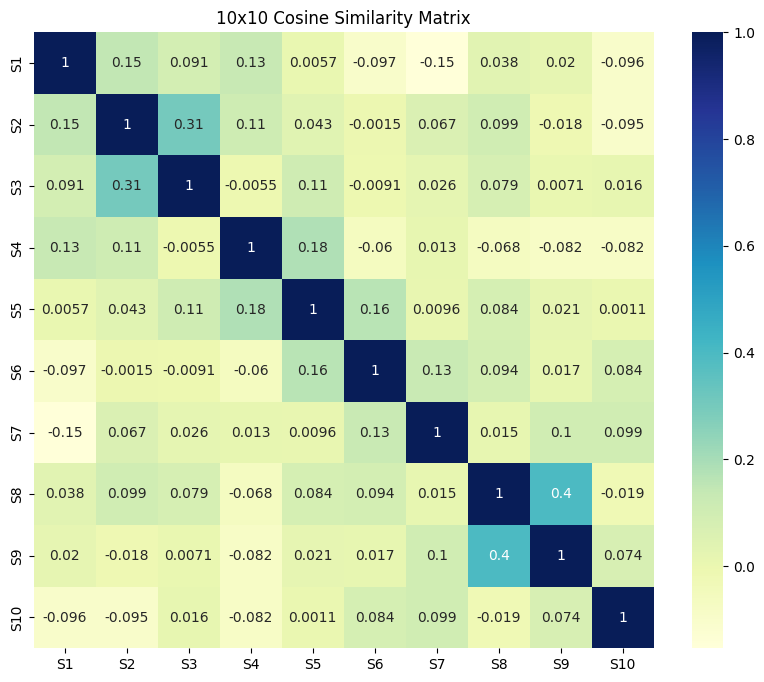

In [22]:
# Compute and display a 10x10 cosine similarity matrix and heatmap
sim_matrix = util.cos_sim(embeddings, embeddings).numpy()
plt.figure(figsize=(10, 8))
sns.heatmap(sim_matrix, annot=True, cmap='YlGnBu',
            xticklabels=[f"S{i+1}" for i in range(10)],
            yticklabels=[f"S{i+1}" for i in range(10)])
plt.title("10x10 Cosine Similarity Matrix")
plt.show()


In [21]:
# Semantic search for top 2 matches
query_sentence = "The bowler took three wickets in one over."
query_embedding = model.encode(query_sentence)
# Find 2 top matches against the query
hits = util.semantic_search(query_embedding, embeddings, top_k=2)[0]

print(f"Query: {query_sentence}")
print("-" * 50)
for hit in hits:
    idx = hit['corpus_id']
    score = hit['score']
    print(f"Match: {sentences[idx]}")
    print(f"Similarity Score: {score:.4f}\n")



Query: The bowler took three wickets in one over.
--------------------------------------------------
Match: T20 format cricket is the best form of modern day cricket.
Similarity Score: 0.3497

Match: Fielding in slip position is all about reflexes, split second decision making is necessary.
Similarity Score: 0.2846

